# 03. VQ-VAE Results
Inspect reconstructions, prior samples, codebook perplexity, and FID.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import yaml
from IPython.display import Image as IPImage

from src.models.vqvae import VQVAE, PixelCNN
from src.utils.seed import set_seed
from src.utils.visualization import save_image_grid
from src.evaluation.fid import save_samples, compute_fid

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

with open('../configs/vqvae_config.yaml', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)
mc, pc = cfg['model'], cfg['prior']

Device: cuda


In [2]:
CKPT = '../checkpoints/vqvae/vqvae_epoch0100.pt'
vqvae = VQVAE(in_channels=mc['in_channels'], hidden_channels=mc['hidden_channels'],
              embedding_dim=mc['embedding_dim'], num_embeddings=mc['num_embeddings'],
              commitment_cost=mc['commitment_cost'], decay=mc['decay']).to(device)
state = torch.load(CKPT, map_location=device)
vqvae.load_state_dict(state['model'])
vqvae.eval()
print(f"Codebook perplexity: {vqvae.vq.perplexity_last:.1f}")

Codebook perplexity: 403.3


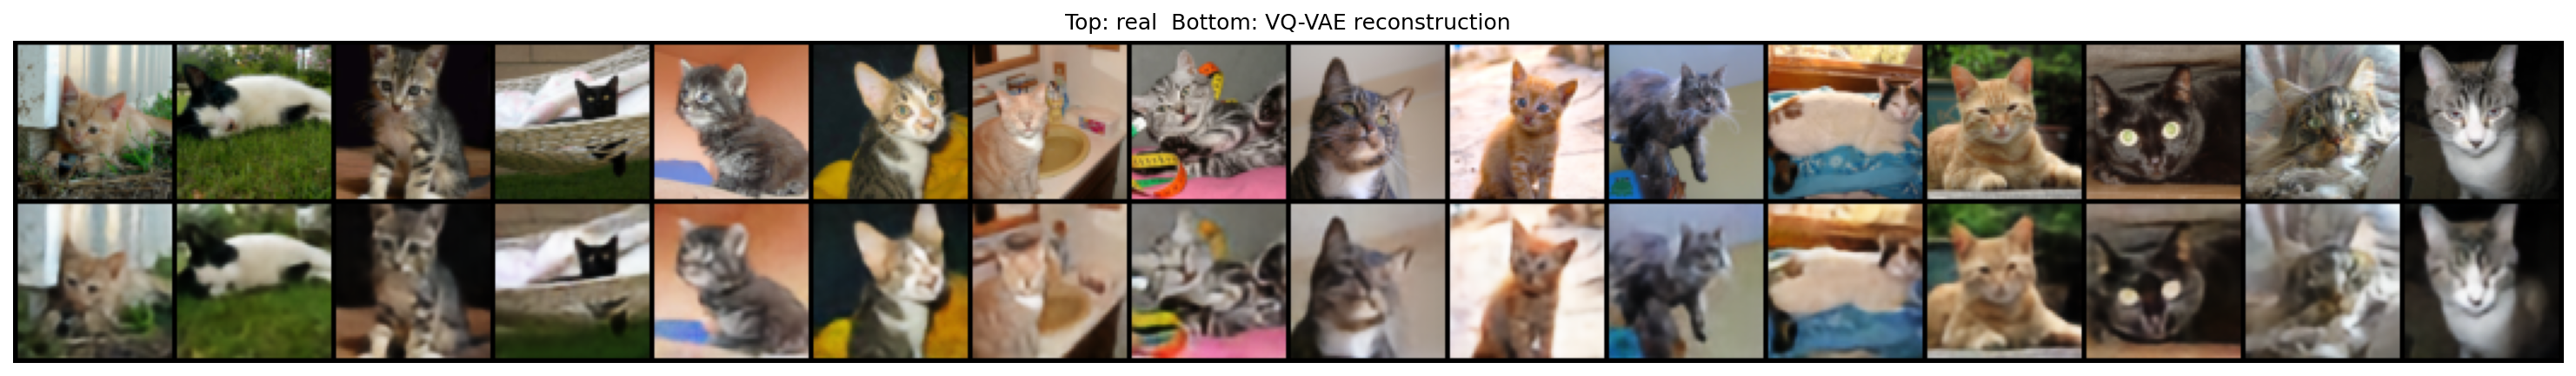

In [3]:
from src.data.preprocessing import get_cat_loader
loader = get_cat_loader('../data/cats', image_size=64, batch_size=32, num_workers=0)
real = next(iter(loader)).to(device)
with torch.no_grad():
    x_recon, _, _ = vqvae(real)
combined = torch.cat([real[:16], x_recon[:16]], dim=0)
save_image_grid(combined, '../outputs/vqvae/notebook_recon.png',
                nrow=16, title='Top: real  Bottom: VQ-VAE reconstruction')
IPImage('../outputs/vqvae/notebook_recon.png')

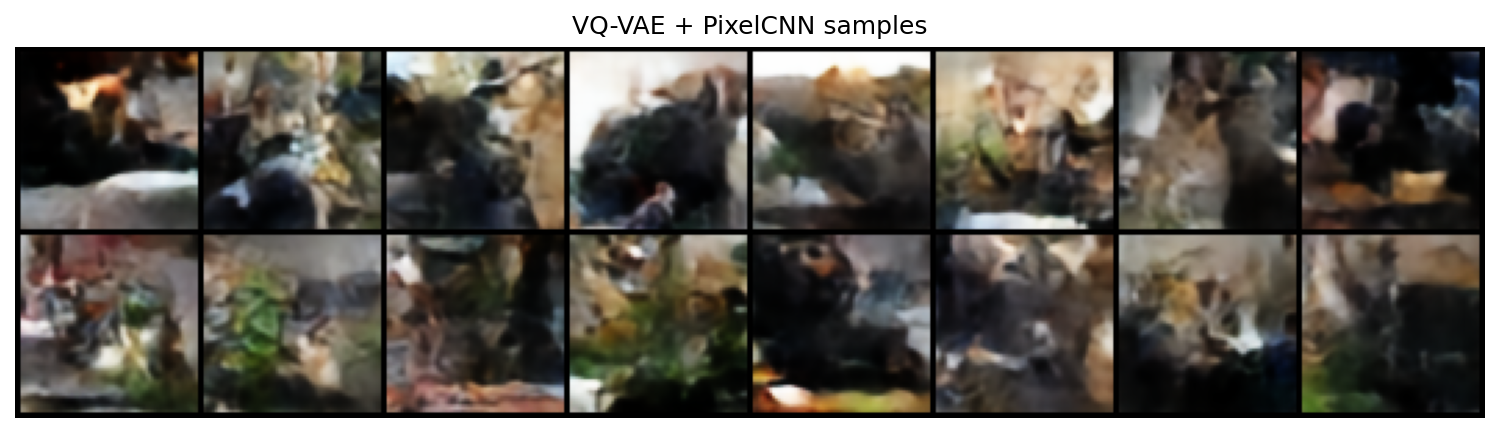

In [4]:
PRIOR_CKPT = '../checkpoints/vqvae/prior_epoch0100.pt'
prior = PixelCNN(mc['num_embeddings'], pc['n_layers'], pc['n_filters']).to(device)
ps = torch.load(PRIOR_CKPT, map_location=device)
prior.load_state_dict(ps['prior'])
prior.eval()

H_z = W_z = 16  # 64 // 4
with torch.no_grad():
    sampled_indices = prior.sample((16, H_z, W_z), device=device)
    samples = vqvae.decode_indices(sampled_indices)
save_image_grid(samples, '../outputs/vqvae/prior_samples.png', nrow=8, title='VQ-VAE + PixelCNN samples')
IPImage('../outputs/vqvae/prior_samples.png')

In [5]:
all_samples = []
with torch.no_grad():
    while len(all_samples) < 5000:
        n = min(64, 5000 - len(all_samples))
        idx = prior.sample((n, H_z, W_z), device=device)
        imgs = vqvae.decode_indices(idx)
        all_samples.extend(imgs.cpu())
import torch
from torchvision.utils import save_image
from pathlib import Path
out_dir = Path('../outputs/vqvae/fid_samples')
out_dir.mkdir(parents=True, exist_ok=True)
for i, img in enumerate(all_samples):
    save_image((img.clamp(-1,1)+1)/2, out_dir / f'{i:06d}.png')

from src.evaluation.fid import compute_fid
fid = compute_fid('../outputs/real_64', '../outputs/vqvae/fid_samples')
print(f'VQ-VAE FID: {fid:.2f}')

VQ-VAE FID: 187.54
